# Part 3, Task 5 — Travel Recommendation System (visual companion)

`recommendation_system/recommender.py` turns the Task 1 regression model's
hour-by-hour predictions into low-traffic travel-window recommendations.
This notebook calls the exact same `recommend()` function — no logic is
duplicated here — across a few scenarios, and visualises the full 24-hour
predicted-volume curve rather than just the top few windows.

In [1]:
import sys
from pathlib import Path

for _candidate in (Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts"):
    if (_candidate / "common.py").exists():
        sys.path.insert(0, str(_candidate))
        break
for _candidate in (Path.cwd().parent / "recommendation_system", Path.cwd() / "recommendation_system"):
    if (_candidate / "recommender.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

from common import FEATURE_COLUMNS, build_feature_frame
from recommender import MODEL_PATH, _load_model, recommend

import joblib

pd.set_option("display.max_columns", None)
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
model = _load_model()

## Recommendations across a few representative scenarios

In [2]:
scenarios = [
    {"day_type": "weekday", "weather": "Clear"},
    {"day_type": "weekend", "weather": "Clear"},
    {"day_type": "weekday", "weather": "Thunderstorm"},
    {"day_type": "weekday", "weather": "Clear", "is_holiday": True},
]
summary_rows = []
for s in scenarios:
    result = recommend(**s)
    best = result["windows"][0]
    summary_rows.append({
        "day_type": s["day_type"], "weather": s["weather"],
        "is_holiday": s.get("is_holiday", False),
        "best_hour": f"{best['hour']:02d}:00", "predicted_volume": best["predicted_volume"],
    })
    print(result["message"])
summary = pd.DataFrame(summary_rows)
summary

For a weekday journey in clear weather, consider travelling between 22:00 and 23:00, when model-predicted traffic volumes are typically lower (~2091 vehicles/hour).
For a weekend journey in clear weather, consider travelling between 06:00 and 07:00, when model-predicted traffic volumes are typically lower (~1383 vehicles/hour).
For a weekday journey in thunderstorm weather, consider travelling between 22:00 and 23:00, when model-predicted traffic volumes are typically lower (~1905 vehicles/hour).
For a weekday journey (public holiday) in clear weather, consider travelling between 22:00 and 23:00, when model-predicted traffic volumes are typically lower (~2443 vehicles/hour).


,day_type,weather,is_holiday,best_hour,predicted_volume
0,weekday,Clear,False,22:00,2091.0
1,weekend,Clear,False,06:00,1383.0
2,weekday,Thunderstorm,False,22:00,1905.0
3,weekday,Clear,True,22:00,2443.0


## Full 24-hour predicted-volume curve

The recommender only surfaces the lowest-traffic windows, but seeing the
whole day's predicted curve makes it clear *why* those windows were
chosen — and confirms the model reproduces the expected bimodal commute
pattern from Part 1/2, even though it was never told about "rush hour"
directly.

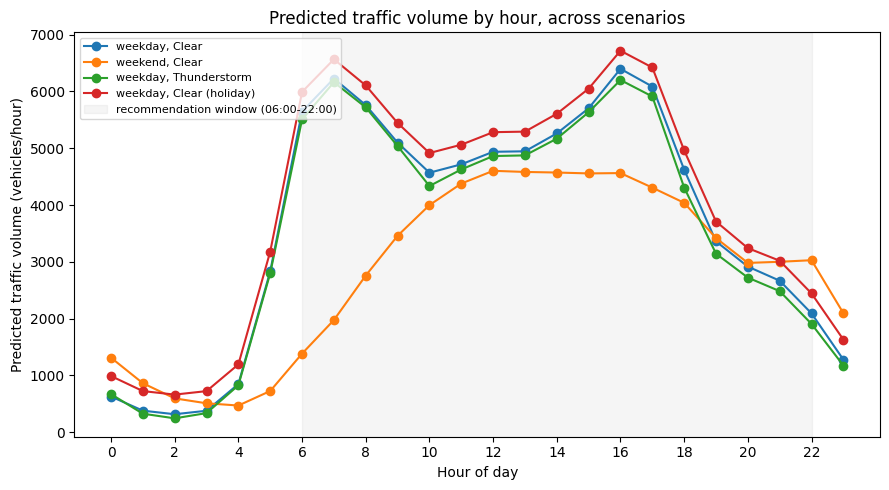

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for s in scenarios:
    scenario_df = build_feature_frame(range(24), s["day_type"], s["weather"], s.get("is_holiday", False))
    scenario_df["predicted_volume"] = model.predict(scenario_df[FEATURE_COLUMNS])
    label = f"{s['day_type']}, {s['weather']}" + (" (holiday)" if s.get("is_holiday") else "")
    ax.plot(scenario_df["hour"], scenario_df["predicted_volume"], marker="o", label=label)

ax.axvspan(6, 22, color="grey", alpha=0.08, label="recommendation window (06:00-22:00)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Predicted traffic volume (vehicles/hour)")
ax.set_title("Predicted traffic volume by hour, across scenarios")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "recommender_scenarios.png", dpi=120)
plt.show()